# EDA: Dataset 1 - Academic Performance


## 1. Import Required Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
PALETTE = {0: '#378ADD', 1: '#EF9F27', 2: '#E24B4A'}

## 2. Load the Dataset

In [34]:
# Load the core clustering dataset
df = pd.read_csv('Dataset_1_Academic_Performance/dataset1_academic_core_clustering.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (899, 20)


,source_dataset,local_student_id,year_level,academic_avg_20,semester1_avg_20,semester2_avg_20,course_grade_mean_20,course_grade_std_20,course_grade_min_20,course_grade_max_20,course_count,failed_course_count_est,failed_course_rate,strong_course_rate,low_performance_rate,performance_consistency_index,academic_risk_score,missing_raw_values_count,missing_core_features_before_imputation,was_imputed
0,annual_deliberation_y1,ADY1_0001,Y1,12.468,13.193,11.904,13.376,2.695,9.75,18.00,12,1,0.083,0.417,0.000,0.731,0.241,0,0,False
1,annual_deliberation_y1,ADY1_0002,Y1,15.878,15.833,15.913,15.773,1.143,13.80,17.45,12,0,0.000,0.833,0.000,0.886,0.119,0,0,False
2,annual_deliberation_y1,ADY1_0003,Y1,9.072,12.061,6.747,9.857,3.620,3.05,14.00,12,4,0.333,0.083,0.333,0.638,0.452,0,0,False
3,annual_deliberation_y1,ADY1_0004,Y1,9.062,10.248,8.140,10.591,4.415,5.00,17.40,12,6,0.500,0.333,0.333,0.559,0.498,0,0,False
4,annual_deliberation_y1,ADY1_0005,Y1,15.170,14.609,15.607,15.215,1.596,13.45,17.90,12,0,0.000,0.667,0.000,0.840,0.141,0,0,False


## 3. Display Basic Dataset Information

In [35]:

df.info()
print("\n" + "=" * 80)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   source_dataset                           899 non-null    object 
 1   local_student_id                         899 non-null    object 
 2   year_level                               899 non-null    object 
 3   academic_avg_20                          899 non-null    float64
 4   semester1_avg_20                         899 non-null    float64
 5   semester2_avg_20                         899 non-null    float64
 6   course_grade_mean_20                     899 non-null    float64
 7   course_grade_std_20                      899 non-null    float64
 8   course_grade_min_20                      899 non-null    float64
 9   course_grade_max_20                      899 non-null    float64
 10  course_count                             899 non-n

## 4. Explore Data Types and Missing Values

In [36]:
# Check for missing values
missing_values = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if missing_values.empty:
    print("No missing values found in the dataset!")
else:
    print(missing_values.to_string(index=False))
    print(f"\nTotal columns with missing values: {len(missing_values)}")


No missing values found in the dataset!


## 5. Generate Descriptive Statistics

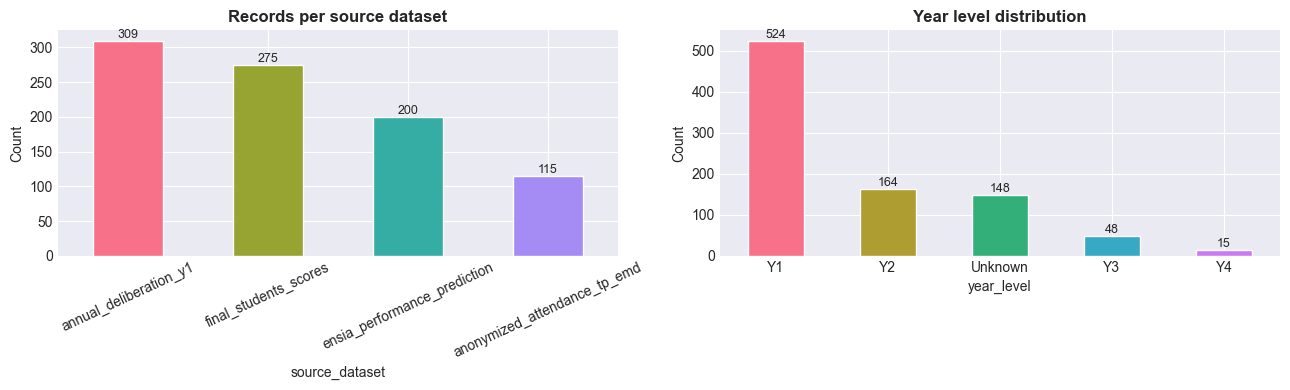

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
##  Source & year-level breakdown
src = df['source_dataset'].value_counts()
src.plot.bar(ax=axes[0], color=sns.color_palette('husl', len(src)), edgecolor='white', rot=25)
axes[0].set_title('Records per source dataset', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

yr = df['year_level'].value_counts()
yr.plot.bar(ax=axes[1], color=sns.color_palette('husl', len(yr)), edgecolor='white', rot=0)
axes[1].set_title('Year level distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()




In [32]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
stats = df[num_cols].describe().T
stats['skewness'] = df[num_cols].skew().round(3)
stats['kurtosis'] = df[num_cols].kurt().round(3)
stats.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
academic_avg_20,899.0,12.372,3.076,0.000,11.750,12.665,13.760,19.750,-1.778,6.143
semester1_avg_20,899.0,13.115,2.351,0.000,12.000,13.403,14.534,18.000,-2.166,8.860
semester2_avg_20,899.0,11.832,2.356,0.000,11.425,12.001,12.928,18.429,-2.001,8.699
course_grade_mean_20,899.0,13.394,3.084,0.000,12.888,13.941,14.735,19.750,-2.473,8.451
course_grade_std_20,899.0,2.417,1.364,0.000,1.862,2.109,2.570,10.177,2.414,8.692
course_grade_min_20,899.0,9.963,3.635,0.000,8.000,11.794,12.000,19.500,-0.762,1.075
course_grade_max_20,899.0,16.773,3.243,0.000,16.000,17.933,18.013,20.000,-3.798,16.550
course_count,899.0,8.092,6.540,0.000,0.000,12.000,12.000,38.000,0.399,0.739
failed_course_count_est,899.0,1.081,2.017,0.000,0.000,0.000,1.000,13.000,2.584,7.358
failed_course_rate,899.0,0.126,0.228,0.000,0.000,0.002,0.167,1.000,2.369,5.556


## 7. Distributions — core performance features

Histograms + KDE for all clustering features, grouped by theme.  
Mean (navy dashed) and median (orange dotted) are overlaid on each plot.


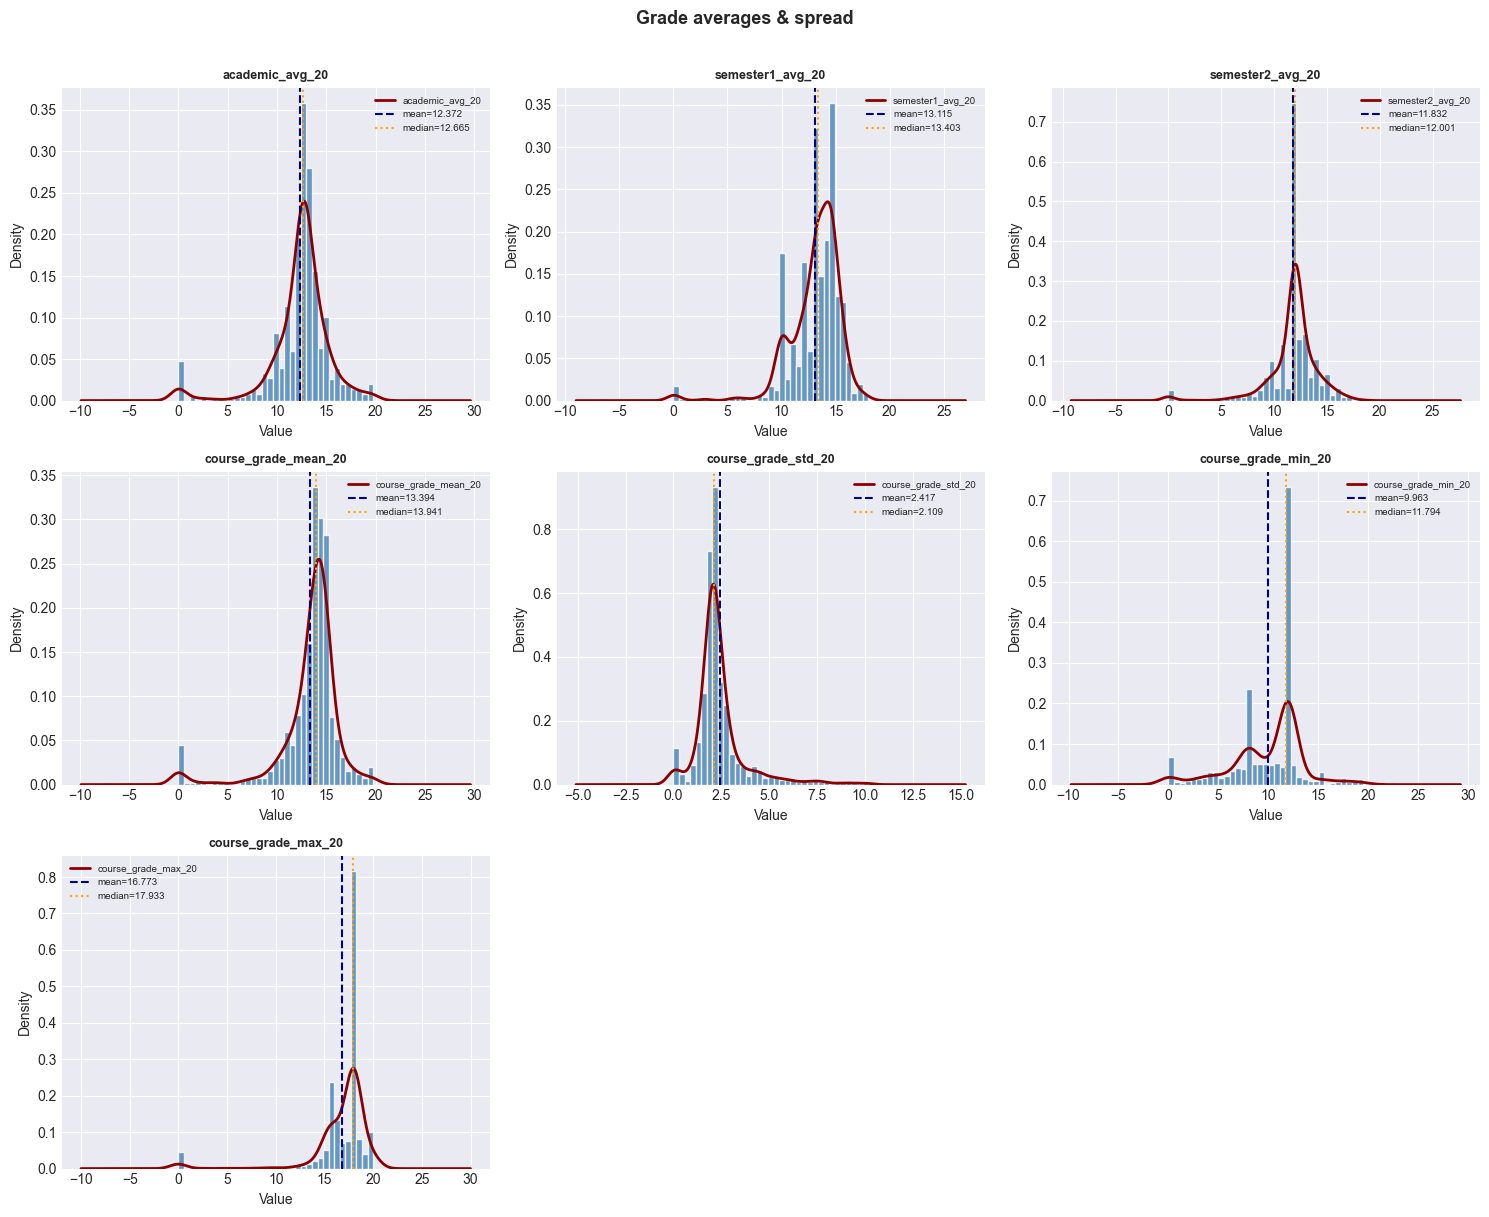

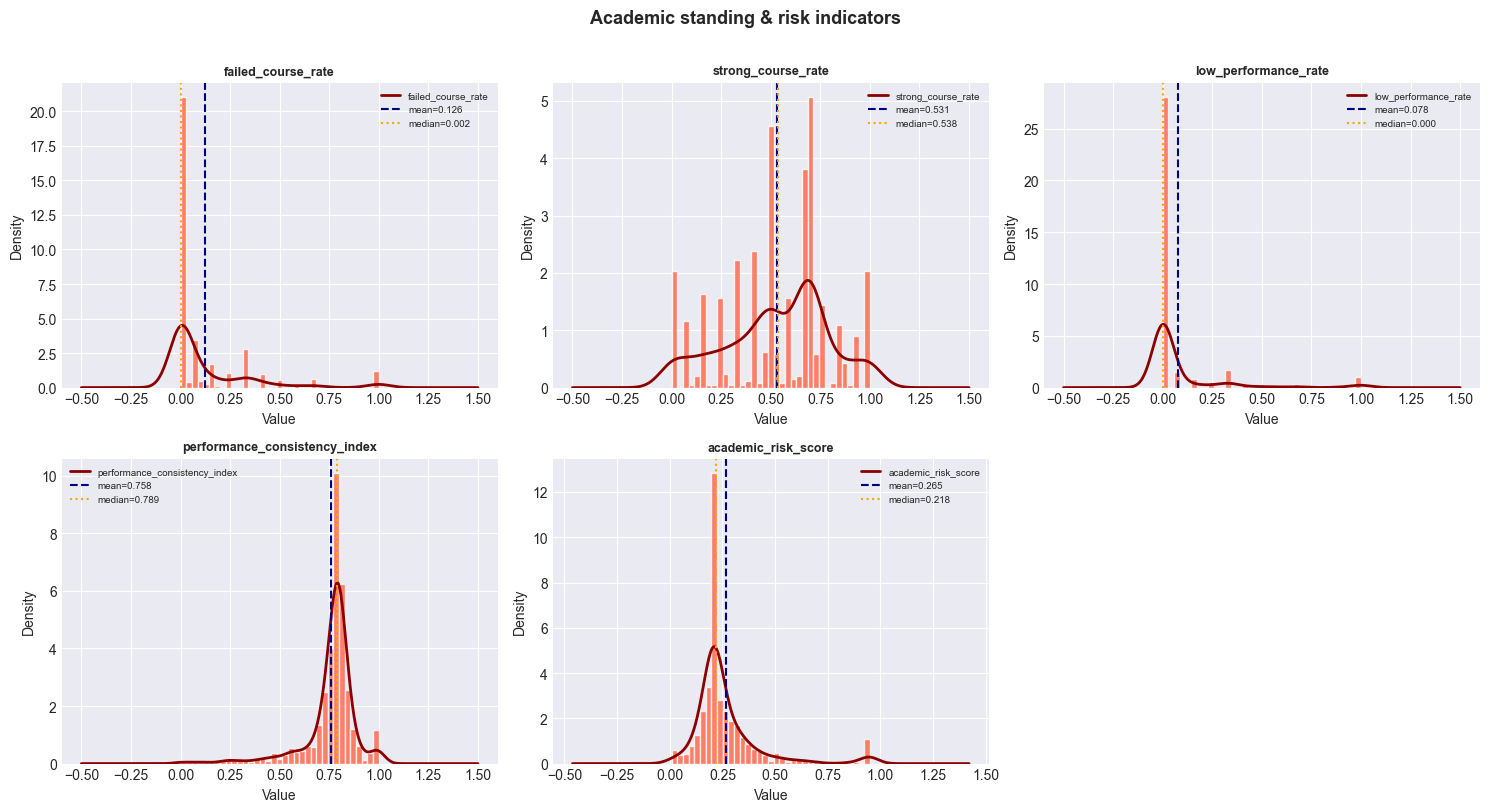

In [40]:
def dist_grid(df, cols, title, color='steelblue', ncols=3):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        data = df[col].dropna()
        axes[i].hist(data, bins=35, color=color, edgecolor='white', alpha=0.8, density=True)
        data.plot.kde(ax=axes[i], color='darkred', linewidth=2)
        axes[i].axvline(data.mean(),   color='navy',   ls='--', lw=1.5, label=f'mean={data.mean():.3f}')
        axes[i].axvline(data.median(), color='orange', ls=':',  lw=1.5, label=f'median={data.median():.3f}')
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].legend(fontsize=7)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Grade averages
grade_cols = ['academic_avg_20', 'semester1_avg_20', 'semester2_avg_20',
              'course_grade_mean_20', 'course_grade_std_20',
              'course_grade_min_20', 'course_grade_max_20']
grade_cols = [c for c in grade_cols if c in df.columns]
dist_grid(df, grade_cols, 'Grade averages & spread', color='steelblue')

# Risk & standing
risk_cols = ['failed_course_rate', 'strong_course_rate', 'low_performance_rate',
             'performance_consistency_index', 'academic_risk_score']
risk_cols = [c for c in risk_cols if c in df.columns]
dist_grid(df, risk_cols, 'Academic standing & risk indicators', color='tomato', ncols=3)


### Grade averages & spread
`academic_avg_20` is roughly normal, centred at 12.4/20, with a slight left skew — a small tail of very low performers pulls the mean below the median. Semester 1 (mean 13.1) outperforms Semester 2 (mean 11.8), suggesting a performance drop in the second term. `course_grade_max_20` clusters tightly near 17–18, meaning almost every student has at least one strong module. `course_grade_min_20` has a secondary spike near 0, reflecting students who failed at least one course badly.
### Academic standing & risk indicators
`failed_course_rate` and `low_performance_rate` are both heavily right-skewed with medians near 0 — most students fail few or no courses, but a clear minority tail drives the mean up. `strong_course_rate` is roughly bimodal, separating students who consistently score well from those who rarely do. `performance_consistency_index` is sharply left-skewed and concentrated near 0.8–0.9, meaning most students are consistent across modules; the left tail captures high-variance students. `academic_risk_score` follows the same right-skewed pattern — the bulk of students sit well below the 0.5 threshold, confirming that at-risk students are a genuine minority and not a gradual continuum, which justifies both the 0.5 threshold choice and the class imbalance handling in Section 12

## 8. Outlier analysis (IQR method)

Mild outliers: beyond 1.5 × IQR. Extreme outliers: beyond 3 × IQR.

=== Outlier summary ===
                                   Q1      Q3    IQR  mild_outliers  mild_pct  extreme_outliers  extreme_pct
feature                                                                                                     
low_performance_rate            0.000   0.008  0.008            183     20.36               179        19.91
performance_consistency_index   0.743   0.814  0.071            138     15.35                53         5.90
academic_risk_score             0.199   0.286  0.087            117     13.01                50         5.56
academic_avg_20                11.750  13.760  2.010             97     10.79                33         3.67
failed_course_rate              0.000   0.167  0.167             69      7.68                32         3.56
strong_course_rate              0.333   0.700  0.367              0      0.00                 0         0.00


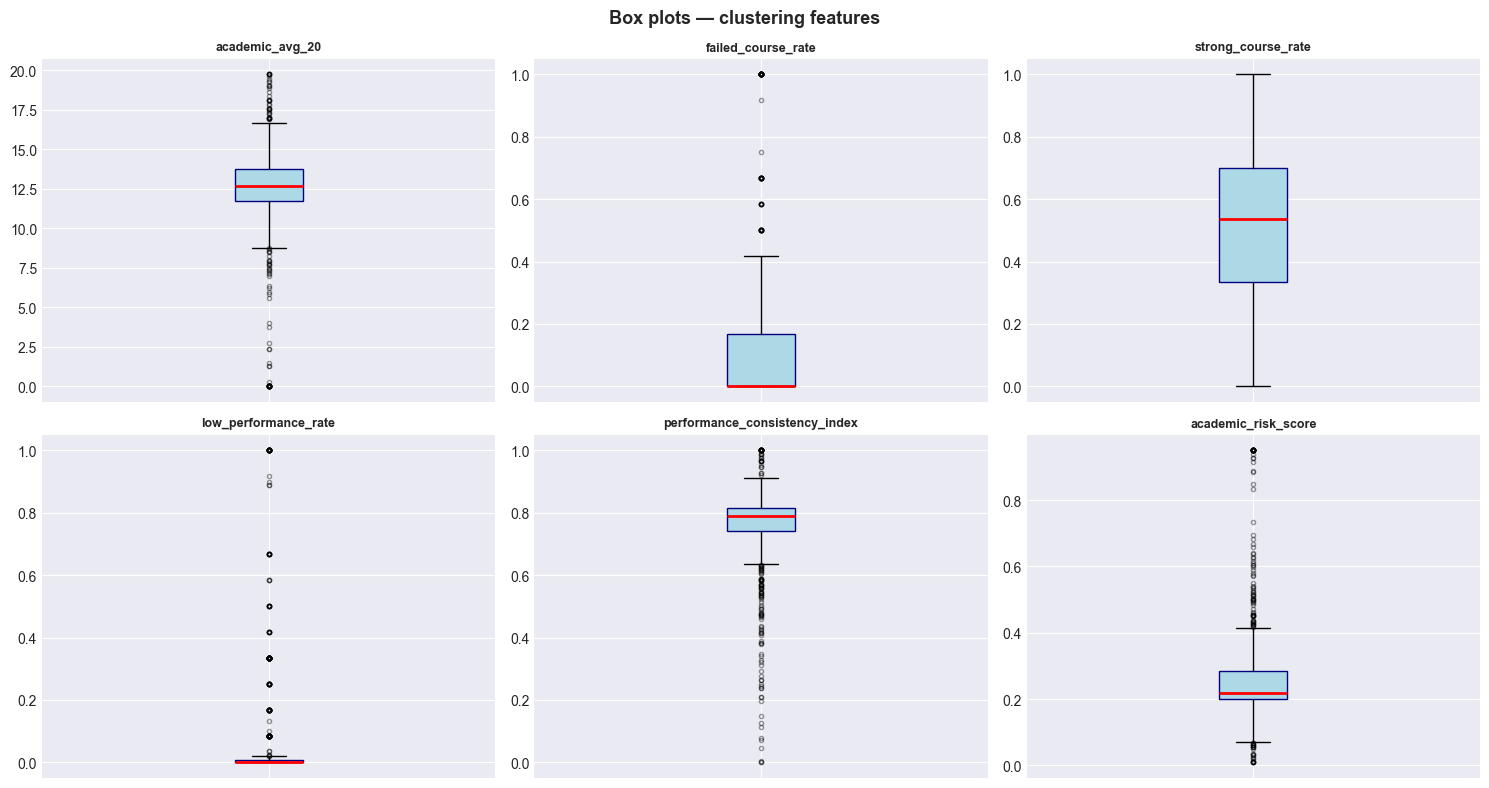

In [41]:
def iqr_outliers(df, cols):
    rows = []
    for c in cols:
        s = df[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        mild  = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
        ext   = ((s < q1 - 3.0*iqr) | (s > q3 + 3.0*iqr)).sum()
        rows.append({
            'feature': c, 'Q1': round(q1, 3), 'Q3': round(q3, 3), 'IQR': round(iqr, 3),
            'mild_outliers': mild, 'mild_pct': round(mild/len(s)*100, 2),
            'extreme_outliers': ext, 'extreme_pct': round(ext/len(s)*100, 2)
        })
    return pd.DataFrame(rows).set_index('feature')

CLUSTER_COLS  = [
    'academic_avg_20', 'failed_course_rate', 'strong_course_rate',
    'low_performance_rate', 'performance_consistency_index', 'academic_risk_score'
]
outlier_report = iqr_outliers(df, CLUSTER_COLS)
print('=== Outlier summary ===')
print(outlier_report.sort_values('mild_pct', ascending=False).to_string())

# Box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(CLUSTER_COLS):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticklabels([])
fig.suptitle('Box plots — clustering features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



## 9. Academic risk score deep-dive

`academic_risk_score` is the primary at-risk signal.  
We examine its distribution, natural breakpoints, and variation by source and year level.


At-risk students (score >= 0.5): 64 / 899  (7.1%)


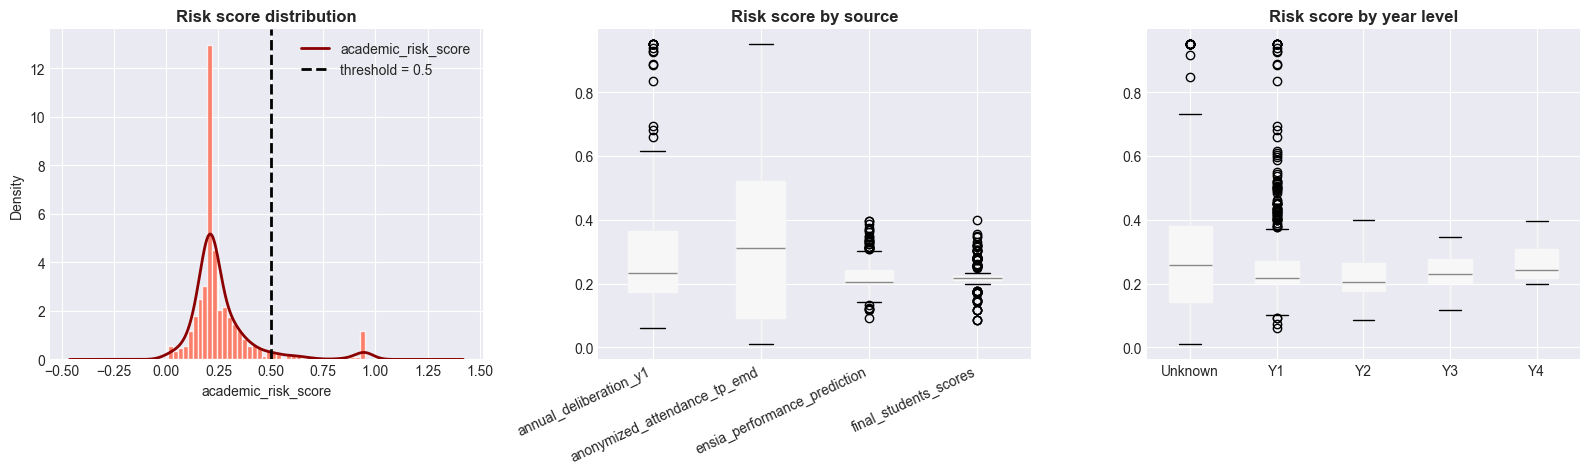

In [43]:
df['at_risk_label'] = (df['academic_risk_score'] >= 0.5).astype(int)
at_risk_n   = df['at_risk_label'].sum()
at_risk_pct = at_risk_n / len(df) * 100
print(f'At-risk students (score >= {0.5}): {at_risk_n} / {len(df)}  ({at_risk_pct:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
risk = df['academic_risk_score'].dropna()
axes[0].hist(risk, bins=40, color='tomato', edgecolor='white', alpha=0.8, density=True)
risk.plot.kde(ax=axes[0], color='darkred', linewidth=2)
axes[0].axvline(0.5, color='black', ls='--', lw=2, label=f'threshold = {0.5}')
axes[0].set_title('Risk score distribution', fontweight='bold')
axes[0].set_xlabel('academic_risk_score')
axes[0].legend()

# By source
df.boxplot(column='academic_risk_score', by='source_dataset', ax=axes[1],
             patch_artist=True, notch=False)
axes[1].set_title('Risk score by source', fontweight='bold')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.xticks(rotation=25, ha='right')

# By year level
df.boxplot(column='academic_risk_score', by='year_level', ax=axes[2],
             patch_artist=True, notch=False)
axes[2].set_title('Risk score by year level', fontweight='bold')
axes[2].set_xlabel('')

fig.suptitle('')
plt.tight_layout()
plt.show()



By year level, Y1 stands out with the most high-risk outliers and the widest spread, which makes sense as first-year students are the most vulnerable to academic shock. Y2–Y4 are more compact and lower, likely reflecting a survivorship effect — weaker students have already left by higher years.

=== Top 12 strongest correlations ===
                    feature_1            feature_2      r
performance_consistency_index  course_grade_std_20 -1.000
          academic_risk_score course_grade_mean_20 -0.965
           failed_course_rate  academic_risk_score  0.948
              academic_avg_20  academic_risk_score -0.946
              academic_avg_20 course_grade_mean_20  0.946
         low_performance_rate  academic_risk_score  0.926
           failed_course_rate low_performance_rate  0.921
           failed_course_rate course_grade_mean_20 -0.890
         low_performance_rate course_grade_mean_20 -0.871
           strong_course_rate course_grade_mean_20  0.807
              academic_avg_20   failed_course_rate -0.806
              academic_avg_20 low_performance_rate -0.793


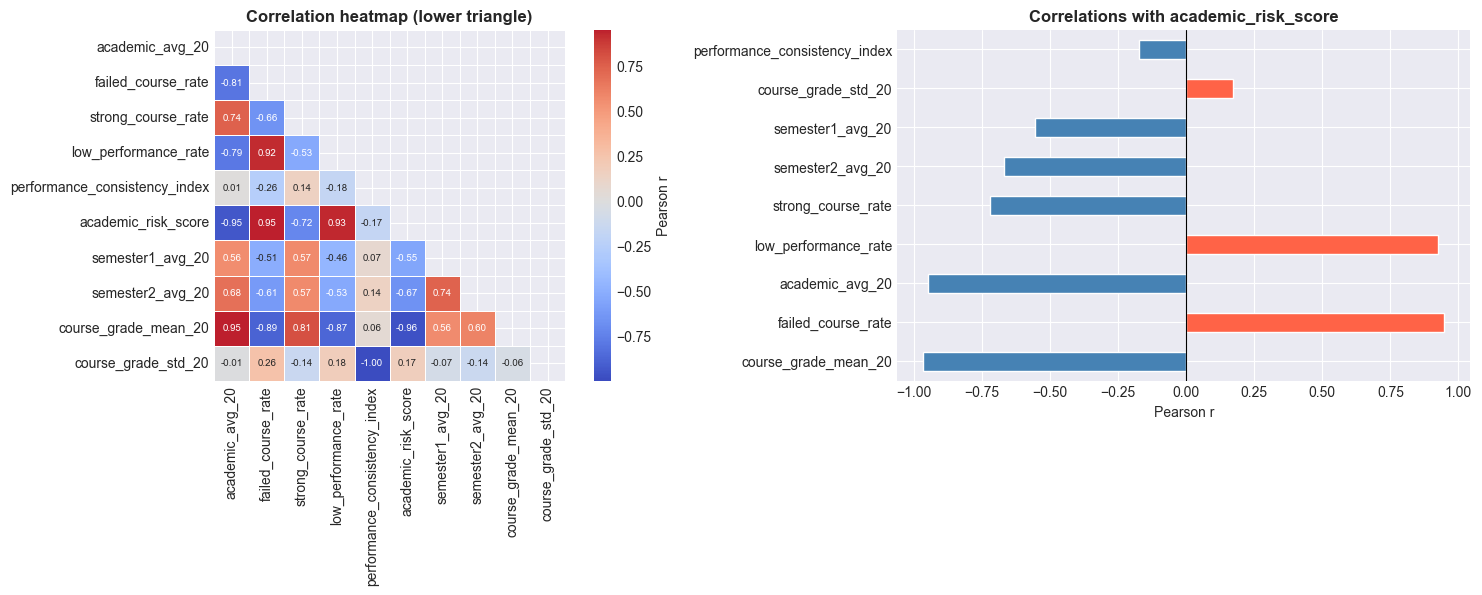

In [44]:
corr_cols = CLUSTER_COLS + ['semester1_avg_20', 'semester2_avg_20',
                         'course_grade_mean_20', 'course_grade_std_20']
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

# Top pairs
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append({'feature_1': corr.columns[i], 'feature_2': corr.columns[j],
                      'r': round(corr.iloc[i,j], 3)})
top_pairs = (pd.DataFrame(pairs)
               .assign(abs_r=lambda d: d['r'].abs())
               .nlargest(12, 'abs_r')[['feature_1','feature_2','r']])
print('=== Top 12 strongest correlations ===')
print(top_pairs.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.4,
            annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Correlation heatmap (lower triangle)', fontweight='bold')

# Bar — correlations with risk score
risk_corr = corr['academic_risk_score'].drop('academic_risk_score').sort_values(key=abs, ascending=False)
colors = ['tomato' if v > 0 else 'steelblue' for v in risk_corr]
risk_corr.plot.barh(ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r')
axes[1].set_title('Correlations with academic_risk_score', fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Pairplot — separability check

Samples 400 rows to keep rendering fast. Coloured by at-risk label.


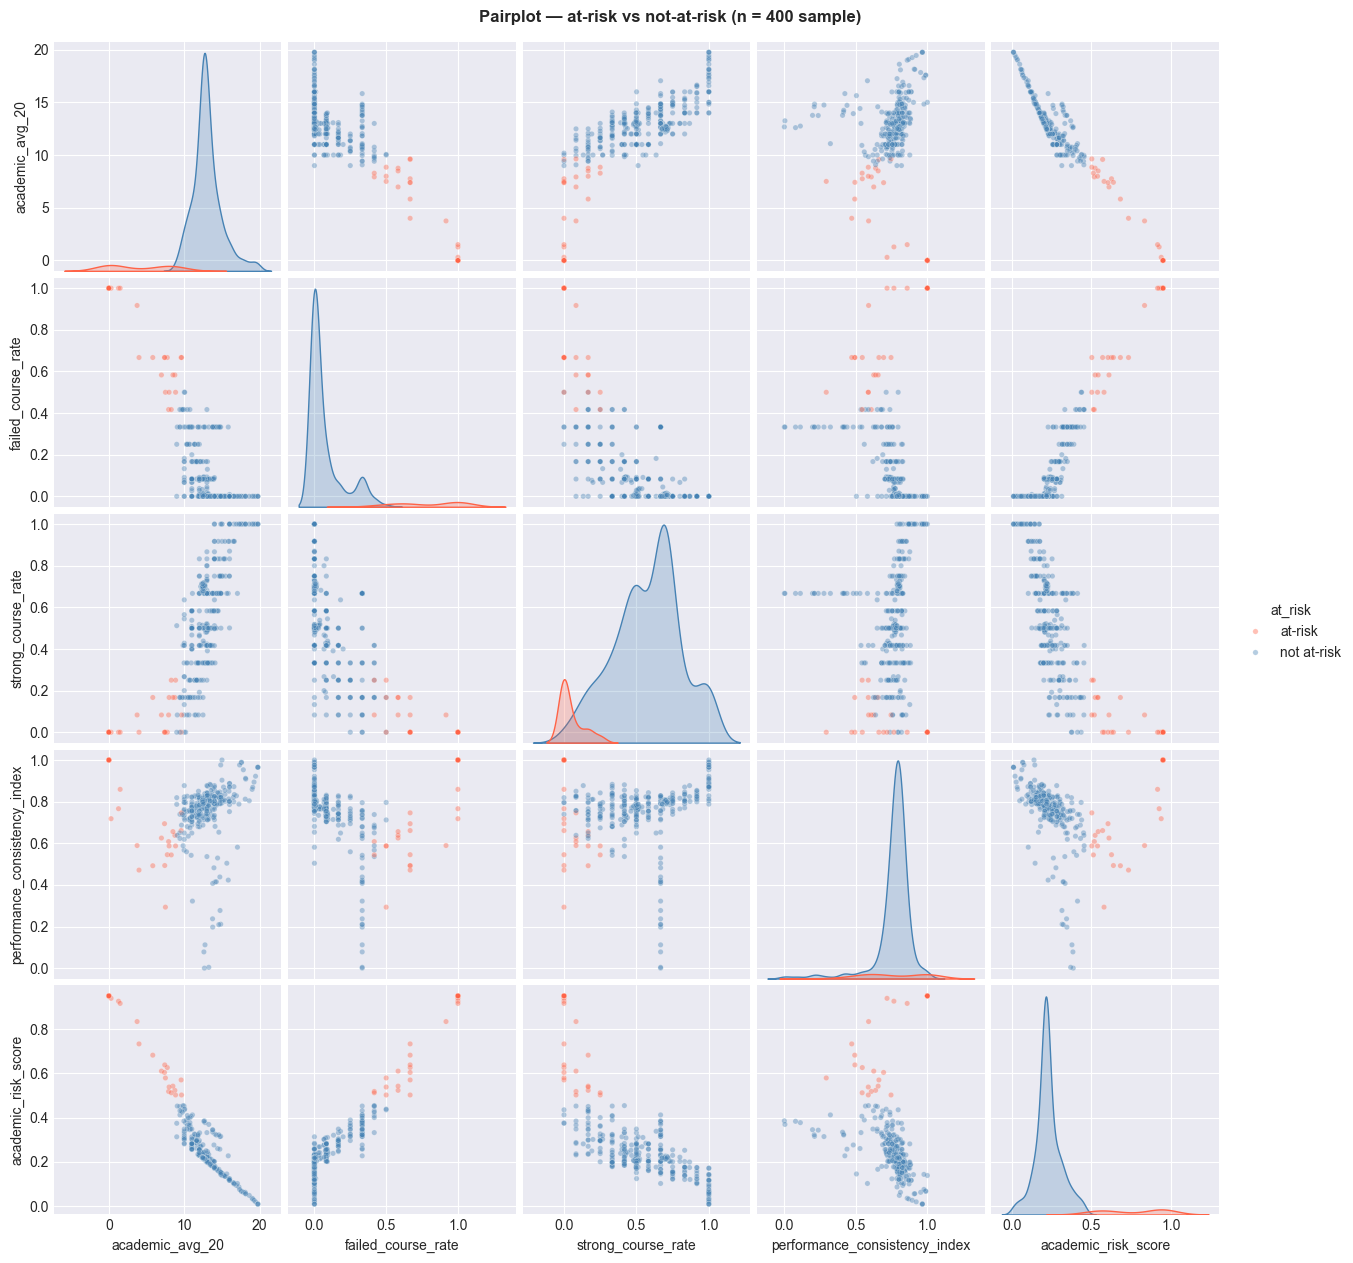

In [45]:
pair_cols = ['academic_avg_20', 'failed_course_rate', 'strong_course_rate',
             'performance_consistency_index', 'academic_risk_score']
pair_cols = [c for c in pair_cols if c in df.columns]

sample = (df[pair_cols + ['at_risk_label']].dropna()
            .sample(min(400, len(df)), random_state=42))
sample['at_risk'] = sample['at_risk_label'].map({0: 'not at-risk', 1: 'at-risk'})

pp = sns.pairplot(sample, vars=pair_cols, hue='at_risk',
                  palette={'not at-risk': 'steelblue', 'at-risk': 'tomato'},
                  plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
pp.fig.suptitle('Pairplot — at-risk vs not-at-risk (n = 400 sample)', y=1.01,
                fontsize=12, fontweight='bold')
plt.show()


## 12. Class imbalance (at-risk label)

=== At-risk label distribution ===
                 count   pct
at_risk_label               
Not at-risk (0)    835  92.9
At-risk (1)         64   7.1

Imbalance ratio: 13.05:1
⚠  Significant imbalance — consider SMOTE or class_weight="balanced"


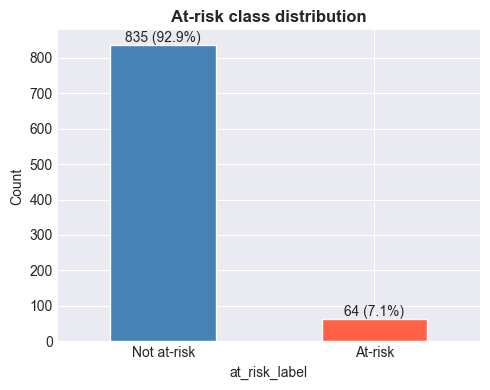

In [46]:
label_counts = df['at_risk_label'].value_counts()
label_pct    = df['at_risk_label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': label_counts, 'pct': label_pct.round(1)})
summary.index = summary.index.map({0: 'Not at-risk (0)', 1: 'At-risk (1)'})
print('=== At-risk label distribution ===')
print(summary.to_string())

ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio: {ratio:.2f}:1')
if ratio > 3:
    print('⚠  Significant imbalance — consider SMOTE or class_weight="balanced"')
else:
    print('✓  Acceptable balance')

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.rename({0: 'Not at-risk', 1: 'At-risk'}).plot.bar(
    ax=ax, color=['steelblue', 'tomato'], edgecolor='white', rot=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_title('At-risk class distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


#  Key findings summary

### Data quality
- **No missing values** in the core clustering file — full imputation was applied upstream.
- `was_imputed` flag covers 112 students (12.5%); their risk-score distribution is similar to non-imputed rows.

### Distributions
- `academic_avg_20` is left-skewed (mean ≈ 12.4/20); most students pass but a tail fails heavily.
- `failed_course_rate` and `low_performance_rate` are strongly right-skewed — the majority of students fail few or no courses.
- `academic_risk_score` is right-skewed (mean 0.265); only 7.1% cross the 0.5 threshold.

### Outliers (IQR)
- `performance_consistency_index` has the most outliers (15.4%) — students with extreme grade variance.
- `academic_risk_score` has 13.0% mild outliers, all high-risk students.

### Correlations
- `course_grade_mean_20`, `failed_course_rate`, and `academic_avg_20` are the three strongest predictors of risk score (|r| > 0.94).
- High multicollinearity among grade-average features — use PCA or feature selection before any classifier.

### Class imbalance
- 64 at-risk students (7.1%) vs 835 not-at-risk (92.9%) — ratio ≈ 13:1.
- Recommendation: use `class_weight='balanced'` or SMOTE when building classifier